In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
from sklearn.preprocessing import StandardScaler 
from sklearn.cluster import KMeans 
from sklearn.metrics import silhouette_score

In [3]:
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [7]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [8]:
df = df.dropna()

In [9]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [10]:
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [13]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

In [14]:
wcss

[399.99999999999994,
 273.6688866264201,
 157.70400815035947,
 109.22822707921347,
 65.56840815571681,
 60.13287487193422,
 49.66824483736798,
 37.319122878338824,
 32.49508119910091,
 30.05932269404221]

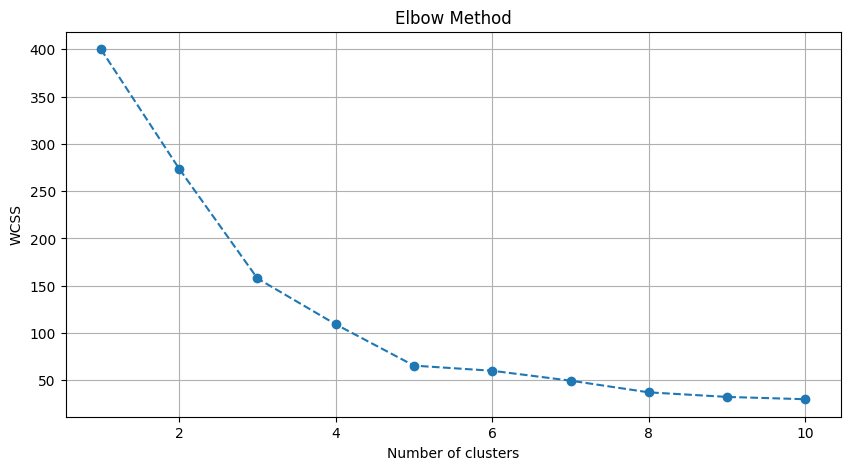

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [16]:
k = 5
kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)

In [17]:
clusters = kmeans.fit_predict(X_scaled)
df['Cluster'] = clusters
print(df['Cluster'].value_counts())

Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


In [18]:
score = silhouette_score(X_scaled, clusters)
print(f'Silhouette Score: {score:.4f}')

Silhouette Score: 0.5547


In [19]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)
print(pd.DataFrame(centers, columns=['Annual Income (k$)', 'Spending Score (1-100)']))

   Annual Income (k$)  Spending Score (1-100)
0           55.296296               49.518519
1           86.538462               82.128205
2           25.727273               79.363636
3           88.200000               17.114286
4           26.304348               20.913043


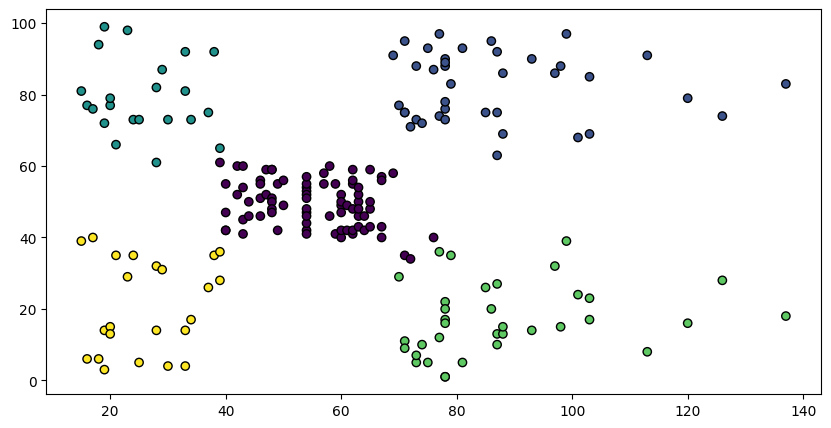

In [23]:
plt.figure(figsize=(10, 5))
plt.scatter(
    df['Annual Income (k$)'], 
    df['Spending Score (1-100)'], 
    c=df['Cluster'], 
    cmap='viridis', 
    marker='o', 
    edgecolor='k'
)
plt.show()

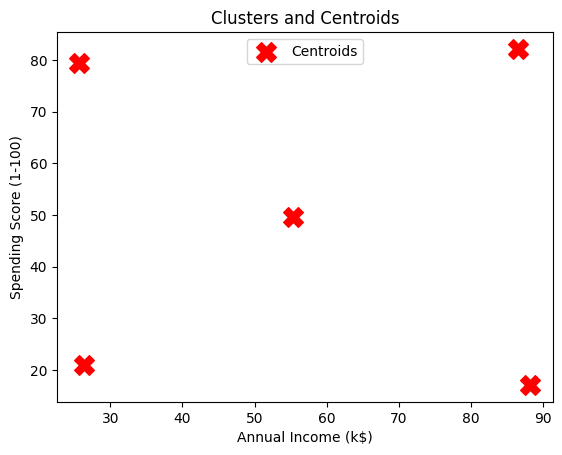

In [25]:
plt.scatter(
    centers[:, 0], 
    centers[:, 1],
    c='red',
    marker='X',
    s=200,
    label='Centroids'
)

plt.title('Clusters and Centroids')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend(loc='upper center')
plt.show()

In [26]:
df.head(20)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
5,6,Female,22,17,76,2
6,7,Female,35,18,6,4
7,8,Female,23,18,94,2
8,9,Male,64,19,3,4
9,10,Female,30,19,72,2


In [27]:
list(range(k))

[0, 1, 2, 3, 4]

In [28]:
for i in range(k):
    cluster_data = df[df['Cluster'] == i]
    print('Customers: ', len(cluster_data))
    print('Average Annual Income: ', cluster_data['Annual Income (k$)'].mean())
    print('Average Spending Score: ', cluster_data['Spending Score (1-100)'].mean())

Customers:  81
Average Annual Income:  55.2962962962963
Average Spending Score:  49.51851851851852
Customers:  39
Average Annual Income:  86.53846153846153
Average Spending Score:  82.12820512820512
Customers:  22
Average Annual Income:  25.727272727272727
Average Spending Score:  79.36363636363636
Customers:  35
Average Annual Income:  88.2
Average Spending Score:  17.114285714285714
Customers:  23
Average Annual Income:  26.304347826086957
Average Spending Score:  20.91304347826087
